# Bayesian Linear Regression

A simple toy example using bayesian linear regression.

In [8]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from pai import BLR
from selection import cross_validation
from scoring import mean_squared_error

mpl.rc_file_defaults()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Toy Data

In [9]:
rng = np.random.default_rng(42)

x_base = np.linspace(-10, 10, 100).reshape((100, 1))
x = rng.uniform(-10, 10, size=(100, 1))
y = x + rng.normal(size=(100, 1)) + 2

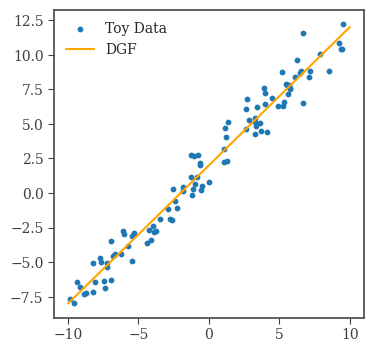

In [10]:
fig, ax = plt.subplots(figsize=(4, 4))

ax.scatter(x, y, label="Toy Data", s=10)
ax.plot(x_base, x_base + 2, label="DGF", color="orange")
ax.legend()

plt.show()

## Fit BLR

In [15]:
blr = BLR(lam=1.0)
blr = blr.fit(x, y)

pred_mu, pred_cov = blr.predict(x)

In [16]:
mean_squared_error(pred_mu, y)

np.float64(65.12772519475746)

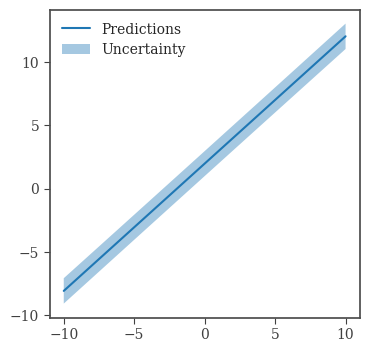

In [13]:
fig, ax = plt.subplots(figsize=(4, 4))

ax.plot(x_base, pred_mu, label=f"Predictions")

std = np.diag(pred_cov) ** 0.5
ax.fill_between(x_base.ravel(), pred_mu - std, pred_mu + std, label="Uncertainty", alpha=0.4)

ax.legend()

plt.show()

## Cross Validation

In [17]:
from sklearn.metrics import mean_squared_error

for lam in [0.001, 0.01, 0.1, 1, 2, 3, 4, 5, 10, 20, 50, 100]:
    blr = BLR(lam=lam)
    score = cross_validation(blr, x, y, mean_squared_error, k=10)

    print(f"BLR with lam = {lam} CV-MSE: {score}")

BLR with lam = 0.001 CV-MSE: 1.0273648506783613
BLR with lam = 0.01 CV-MSE: 0.9981917232052664
BLR with lam = 0.1 CV-MSE: 1.01213369584828
BLR with lam = 1 CV-MSE: 0.9906699304263136
BLR with lam = 2 CV-MSE: 1.0166500481933234
BLR with lam = 3 CV-MSE: 0.9992573935327395
BLR with lam = 4 CV-MSE: 0.9897089118815326
BLR with lam = 5 CV-MSE: 1.006553938092574
BLR with lam = 10 CV-MSE: 1.062100393763463
BLR with lam = 20 CV-MSE: 1.1878879182747462
BLR with lam = 50 CV-MSE: 1.503400190546345
BLR with lam = 100 CV-MSE: 2.16449998817744
